# PPG-Based Physiological State Classification

**Classification of resting (sitting) versus active (running) physiological states using PPG signal features and a Random Forest classifier.**

### Project evolution
The project initially aimed to estimate or classify blood pressure from PPG signals. After examining the available data, the objective was refined because the selected PhysioNet dataset provides PPG recordings under controlled activity conditions rather than continuous blood-pressure labels. The final study therefore uses **sitting versus running** as a binary physiological-state classification problem.

A preliminary model was first developed using approximately 40 recordings without segmentation. Although it achieved about **87.5% accuracy**, only about eight recordings were in the test set. To obtain a more informative evaluation, the recordings were subsequently divided into fixed-length windows and features were extracted from each window.

## 1. Dataset and Experimental Design

Data are obtained from the **PhysioNet Pulse Transit Time PPG Database**. The database contains physiological recordings from approximately 22 subjects under sitting, walking, and running conditions. This project uses only the **`pleth_1` PPG channel** and the **sit** and **run** conditions.

The final analysis uses the available sit/run recordings as the source recordings and divides them into five-second PPG windows. Walking recordings are excluded because the final task is binary classification of resting versus active state.

> **Important:** the number of segmented windows is not the number of independent subjects. Multiple windows can originate from the same subject/recording, which is considered as a limitation of the current evaluation.

In [1]:
# Install dependencies in Google Colab if needed
!pip install -q wfdb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 3.0 MB/s eta 0:00:00


### 1.1 Data acquisition

For reproducibility, the notebook downloads only the `.hea` and `.dat` files needed for the sit/run analysis. The `.atr` annotation files are not required because pulse peaks are detected directly from the PPG signal using SciPy.

The raw PhysioNet data are intentionally not included in this GitHub repository.

In [ ]:
from pathlib import Path
import urllib.request
import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = Path('/content/ppg_data')
DATA_DIR.mkdir(parents=True, exist_ok=True)

BASE_URL = 'https://physionet.org/files/pulse-transit-time-ppg/1.1.0'

for subject in range(1, 23):
    for condition in ['sit', 'run']:
        for ext in ['hea', 'dat']:
            filename = f's{subject}_{condition}.{ext}'
            destination = DATA_DIR / filename
            if not destination.exists():
                url = f'{BASE_URL}/{filename}'
                try:
                    urllib.request.urlretrieve(url, destination)
                    print('Downloaded:', filename)
                except Exception as e:
                    print('Unavailable:', filename, '|', e)

print('Data directory:', DATA_DIR)

Downloaded: s1_sit.hea
Downloaded: s1_sit.dat
Downloaded: s1_run.hea
Downloaded: s1_run.dat
Downloaded: s2_sit.hea
Downloaded: s2_sit.dat
Downloaded: s2_run.hea
Downloaded: s2_run.dat
Downloaded: s3_sit.hea
Downloaded: s3_sit.dat
Downloaded: s3_run.hea
Downloaded: s3_run.dat
Downloaded: s4_sit.hea
Downloaded: s4_sit.dat
Downloaded: s4_run.hea
Downloaded: s4_run.dat
Downloaded: s5_sit.hea
Downloaded: s5_sit.dat
Downloaded: s5_run.hea
Downloaded: s5_run.dat
Downloaded: s6_sit.hea
Downloaded: s6_sit.dat
Downloaded: s6_run.hea
Downloaded: s6_run.dat
Downloaded: s7_sit.hea
Downloaded: s7_sit.dat
Downloaded: s7_run.hea
Downloaded: s7_run.dat
Downloaded: s8_sit.hea
Downloaded: s8_sit.dat
Downloaded: s8_run.hea
Downloaded: s8_run.dat
Downloaded: s9_sit.hea
Downloaded: s9_sit.dat
Downloaded: s9_run.hea
Downloaded: s9_run.dat
Downloaded: s10_sit.hea
Downloaded: s10_sit.dat
Downloaded: s10_run.hea
Downloaded: s10_run.dat
Downloaded: s11_sit.hea
Downloaded: s11_sit.dat
Downloaded: s11_run.hea
Down

In [ ]:
# Build a list of records that have BOTH a header and a data file.
# This prevents duplicate/incomplete files from being used accidentally.

record_names = sorted({
    p.stem
    for p in DATA_DIR.glob('*.hea')
    if (DATA_DIR / f'{p.stem}.dat').exists()
    and '(1)' not in p.stem
    and any(condition in p.stem.lower() for condition in ['sit', 'run'])
})

print('Complete sit/run recordings:', len(record_names))
print(record_names)

sit_records = [r for r in record_names if 'sit' in r.lower()]
run_records = [r for r in record_names if 'run' in r.lower()]

print('Sit recordings:', len(sit_records))
print('Run recordings:', len(run_records))

## 2. Representative PPG Signal

Before feature extraction, a representative recording is inspected to verify the signal and demonstrate the processing pipeline. The full time-series view provides context for baseline drift and longer-term variation, while the zoomed view shows individual pulse cycles.

Sampling frequency: 500.0 Hz
Duration: 8.2691 minutes


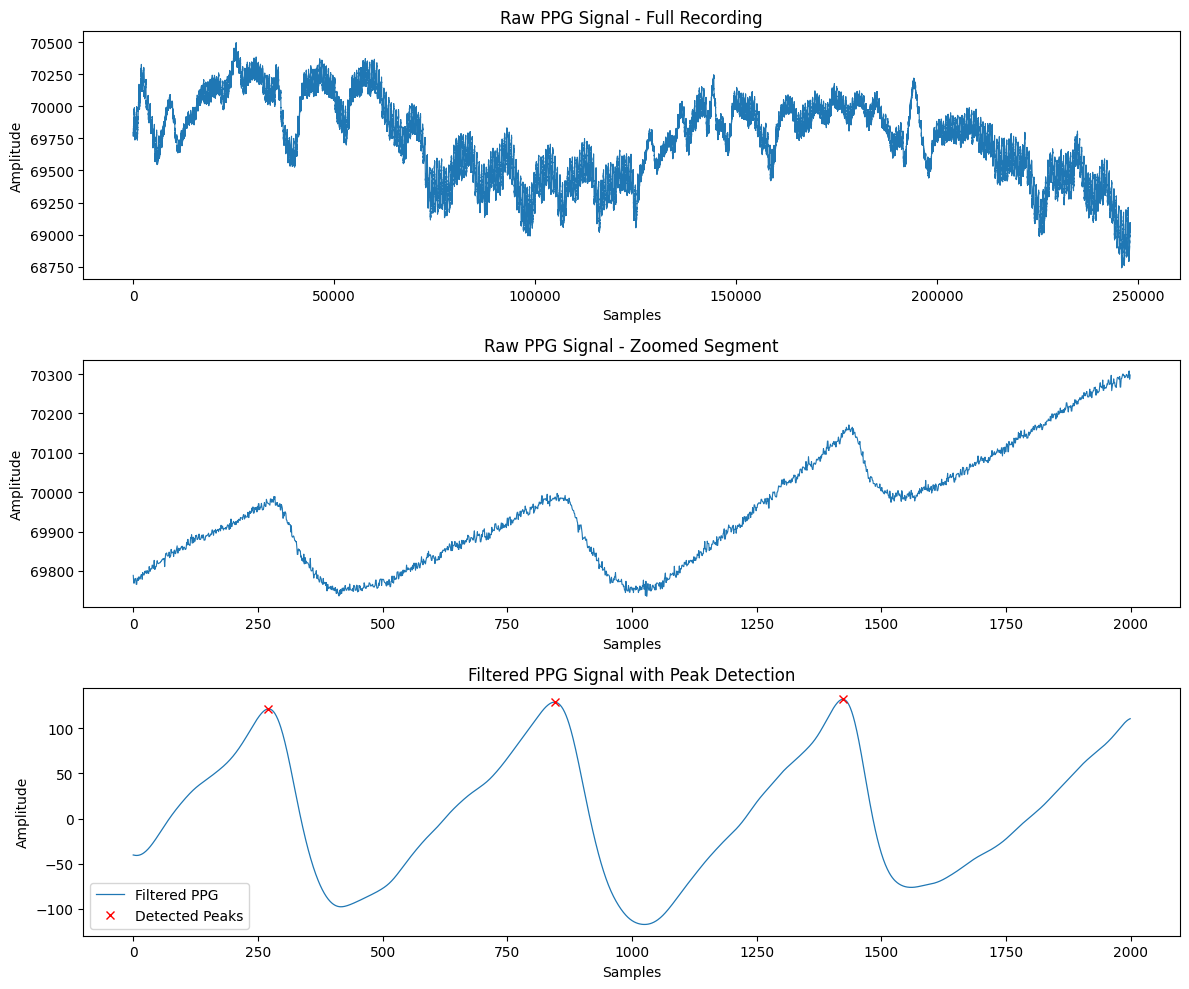

In [6]:
from scipy.signal import butter, filtfilt, find_peaks


def bandpass_filter(signal, fs, low=0.5, high=5.0, order=2):
    """Apply a Butterworth bandpass filter to a PPG signal."""
    nyquist = fs / 2.0
    if not 0 < low < high < nyquist:
        raise ValueError(f'Invalid filter range: {low}-{high} Hz for fs={fs} Hz')
    b, a = butter(order, [low / nyquist, high / nyquist], btype='band')
    return filtfilt(b, a, signal)

representative_name = 's14_sit'
record = wfdb.rdrecord(str(DATA_DIR / representative_name))

ppg = record.p_signal[:, record.sig_name.index('pleth_1')]
fs = float(record.fs)
ppg_filtered = bandpass_filter(ppg, fs)

peaks, _ = find_peaks(
    ppg_filtered,
    distance=int(0.5 * fs)
)

n_zoom = min(2000, len(ppg))
zoom_peaks = peaks[peaks < n_zoom]

print('Sampling frequency:', fs, 'Hz')
print('Duration:', len(ppg) / fs / 60, 'minutes')

fig, axes = plt.subplots(3, 1, figsize=(12, 10))

axes[0].plot(ppg, linewidth=0.8)
axes[0].set_title('Raw PPG Signal - Full Recording')
axes[0].set_xlabel('Samples')
axes[0].set_ylabel('Amplitude')

axes[1].plot(ppg[:n_zoom], linewidth=0.8)
axes[1].set_title('Raw PPG Signal - Zoomed Segment')
axes[1].set_xlabel('Samples')
axes[1].set_ylabel('Amplitude')

axes[2].plot(ppg_filtered[:n_zoom], linewidth=0.9, label='Filtered PPG')
axes[2].plot(zoom_peaks, ppg_filtered[zoom_peaks], 'rx', label='Detected Peaks')
axes[2].set_title('Filtered PPG Signal with Peak Detection')
axes[2].set_xlabel('Samples')
axes[2].set_ylabel('Amplitude')
axes[2].legend()

plt.tight_layout()
plt.savefig('ppg_processing.png', dpi=300, bbox_inches='tight')
plt.show()

## 3. Signal Processing and Feature Extraction

Each selected recording undergoes the same preprocessing pipeline. First, the `pleth_1` channel is extracted. A second-order Butterworth bandpass filter from **0.5 to 5 Hz** is then applied to reduce slow baseline drift and higher-frequency noise while retaining the cardiac pulse waveform. Pulse peaks are detected from the filtered signal using `scipy.signal.find_peaks`.

Each filtered recording is divided into **five-second non-overlapping windows**. Windows with fewer than three detected peaks are excluded because reliable interval-based heart-rate statistics cannot be calculated from them.

For each retained window, four features are calculated:

1. Mean heart rate (`mean_hr`)
2. Standard deviation of heart rate (`std_HR`)
3. Mean pulse amplitude (`mean_amp`)
4. Standard deviation of pulse amplitude (`std_amp`)

In [8]:
import numpy as np
import wfdb
from scipy.signal import butter, filtfilt, find_peaks


def bandpass_filter(signal, fs, low=0.5, high=5.0, order=2):
    nyquist = fs / 2
    b, a = butter(
        order,
        [low / nyquist, high / nyquist],
        btype="band"
    )
    return filtfilt(b, a, signal)


X = []
y = []
record_ids = []

# 5-second NON-overlapping windows
WINDOW_SECONDS = 5

for record_name in record_names:

    try:
        # Load WFDB record
        record = wfdb.rdrecord(str(DATA_DIR / record_name))

        # Verify required PPG channel
        if "pleth_1" not in record.sig_name:
            print(f"Skipping {record_name}: pleth_1 not available")
            continue

        # Extract PPG
        ppg = record.p_signal[
            :, record.sig_name.index("pleth_1")
        ]

        fs = float(record.fs)

        # Filter PPG
        ppg_filtered = bandpass_filter(
            ppg,
            fs,
            low=0.5,
            high=5.0
        )

        # Convert 5 seconds to samples
        window_size = int(WINDOW_SECONDS * fs)

        # Create NON-overlapping windows
        for start in range(
            0,
            len(ppg_filtered) - window_size,
            window_size
        ):

            segment = ppg_filtered[
                start:start + window_size
            ]

            # Detect pulse peaks
            peaks, _ = find_peaks(
                segment,
                distance=int(fs * 0.5)
            )

            # Require at least 3 peaks
            if len(peaks) <= 2:
                continue

            # Pulse-to-pulse intervals in seconds
            peak_intervals = np.diff(peaks) / fs

            # Convert intervals to instantaneous HR
            heart_rate = 60 / peak_intervals

            # Extract four features
            features = [
                np.mean(heart_rate),
                np.std(heart_rate),
                np.mean(segment[peaks]),
                np.std(segment[peaks])
            ]

            X.append(features)

            # Labels:
            # 0 = Sit
            # 1 = Run
            if "sit" in record_name.lower():
                y.append(0)

            elif "run" in record_name.lower():
                y.append(1)

            record_ids.append(record_name)

    except Exception as e:
        print(f"Error processing {record_name}: {e}")


# Convert lists to NumPy arrays
X = np.asarray(X, dtype=float)
y = np.asarray(y, dtype=int)
record_ids = np.asarray(record_ids)

feature_names = [
    "mean_hr",
    "std_HR",
    "mean_amp",
    "std_amp"
]


print("Processing complete")
print("-------------------")
print("Recordings:", len(record_names))
print("Total samples:", len(X))
print("Sit samples:", np.sum(y == 0))
print("Run samples:", np.sum(y == 1))
print("Feature matrix shape:", X.shape)

Processing complete
-------------------
Recordings: 44
Total samples: 4307
Sit samples: 2152
Run samples: 2155
Feature matrix shape: (4307, 4)


## 4. Preliminary Model: Before Segmentation

The preliminary analysis used approximately **40 recordings directly**, generating one feature vector per recording. A Random Forest classifier achieved approximately **87.5% accuracy**, but the 80/20 split left only about **8 test recordings**. Because a single misclassification changes the accuracy by 12.5 percentage points in an eight-sample test set, this estimate was considered too unstable for a final evaluation.

This limitation motivated the windowed segmentation strategy. The preliminary result is retained here to document the development of the project and the methodological change made after the initial analysis.

In [14]:
# Create a DataFrame for inspection
import pandas as pd

features_df = pd.DataFrame(
    X,
    columns=["mean_hr", "std_HR", "mean_amp", "std_amp"]
)

features_df["label"] = y
features_df["record_id"] = record_ids

# Show class balance
print(
    features_df.groupby("label")
    .size()
    .rename(index={0: "Sit", 1: "Run"})
)

print("\nFirst five feature vectors:")
display(features_df.head())

label
Sit    2152
Run    2155
dtype: int64

First five feature vectors:


,mean_hr,std_HR,mean_amp,std_amp,label,record_id
0,108.044174,4.255267,152.229288,46.731031,1,s10_run
1,100.318344,3.555375,109.640231,39.069917,1,s10_run
2,99.434965,7.560165,222.807795,49.520677,1,s10_run
3,101.801962,5.600723,189.989971,36.034782,1,s10_run
4,101.406754,5.562888,187.453994,96.689324,1,s10_run


## 5. Final Machine Learning Model

A **Random Forest classifier** is used as the final supervised learning model. Random Forest was selected because it can model nonlinear relationships among the extracted physiological features and provides feature-importance estimates that support interpretation.

The final dataset is divided using a stratified **80/20 train-test split**. A fixed random seed (`random_state=42`) is used so that the analysis is reproducible. The sit/run classes are approximately balanced, so no class-rebalancing procedure is required.

> **Evaluation limitation:** because the split is performed at the window level, windows from the same recording can appear in both training and testing. Therefore, this result should be interpreted as a window-level baseline rather than a fully subject-independent estimate of generalization.

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print("Accuracy:", model.score(X_test, y_test))

Training samples: 3445
Testing samples: 862
Accuracy: 0.834106728538283


## 6. Final Model Evaluation

In [15]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

# Predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# Classification report
print("Classification Report:\n")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Sit", "Run"]
    )
)

# Confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# ROC-AUC
auc = roc_auc_score(y_test, y_prob)
print(f"\nROC-AUC: {auc:.3f}")

Classification Report:

              precision    recall  f1-score   support

         Sit       0.83      0.84      0.83       431
         Run       0.83      0.83      0.83       431

    accuracy                           0.83       862
   macro avg       0.83      0.83      0.83       862
weighted avg       0.83      0.83      0.83       862

Confusion Matrix:
[[360  71]
 [ 72 359]]

ROC-AUC: 0.916


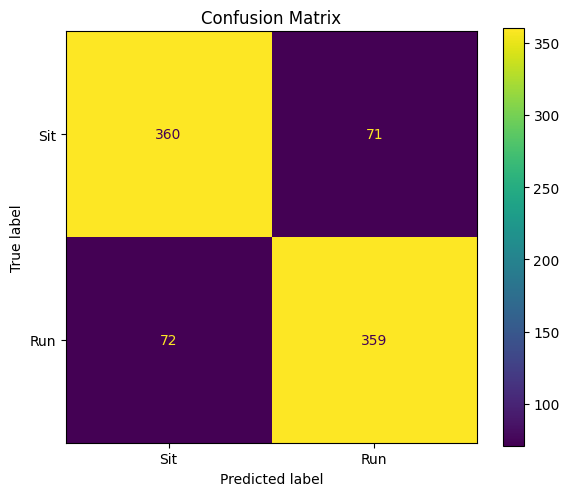

In [17]:
# Confusion matrix

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Sit", "Run"]
)

disp.plot(ax=ax, values_format="d")

ax.set_title("Confusion Matrix")
plt.tight_layout()

plt.savefig(
    "confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

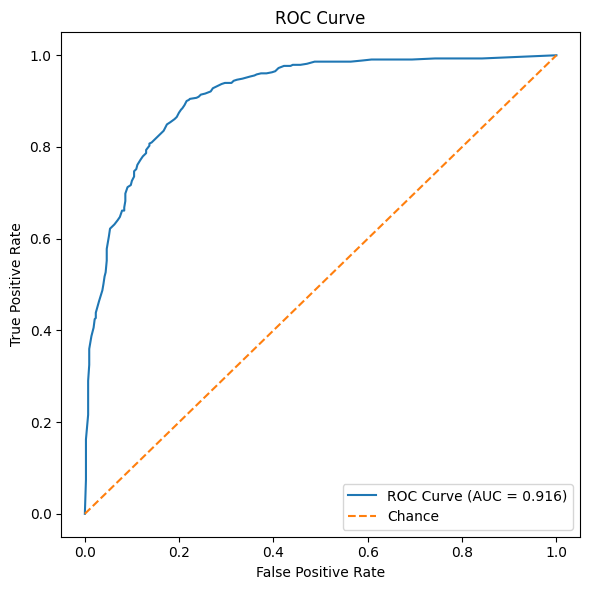

ROC-AUC: 0.916


In [19]:
# ROC curve

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Predicted probabilities for the Run class
y_prob = model.predict_proba(X_test)[:, 1]

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob)

# AUC
auc_value = roc_auc_score(y_test, y_prob)

# Plot
plt.figure(figsize=(6, 6))
plt.plot(
    fpr,
    tpr,
    label=f"ROC Curve (AUC = {auc_value:.3f})"
)
plt.plot(
    [0, 1],
    [0, 1],
    "--",
    label="Chance"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")

plt.tight_layout()

# Save figure
plt.savefig(
    "roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"ROC-AUC: {auc_value:.3f}")

## 7. Feature Importance

Random Forest feature importance is used to determine which extracted PPG features contribute most strongly to classification. The ranking provides an interpretable connection between the machine-learning model and the underlying physiology, while recognizing that feature importance is model-specific and does not establish causation.

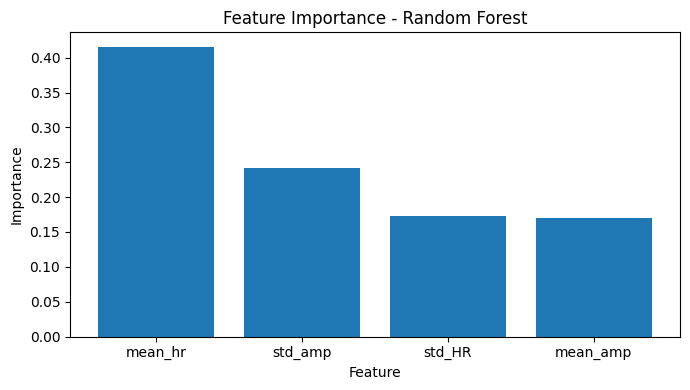

Feature ranking:
mean_hr: 0.4155
std_amp: 0.2416
std_HR: 0.1723
mean_amp: 0.1706


In [20]:
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(7, 4))
plt.bar(
    [feature_names[i] for i in indices],
    importances[indices]
)
plt.title('Feature Importance - Random Forest')
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print('Feature ranking:')
for i in indices:
    print(f'{feature_names[i]}: {importances[i]:.4f}')

## 8. Interpretation and Limitations

The final model provides a window-level baseline for distinguishing sitting from running using a small set of PPG-derived features. Comparable performance of the two classes is important because it indicates that the model is not relying on a strong class imbalance.

Heart-rate features are expected to be informative because physical activity changes cardiovascular demand. Pulse-amplitude features may also contribute because peripheral blood-volume dynamics and the morphology of the PPG waveform can change with physiological state and movement.

The main limitation is that segmentation increases the number of machine-learning samples without increasing the number of independent subjects. With a random window-level split, segments from a common recording can occur in both training and testing, so the reported performance may overestimate performance on a completely unseen participant. A subject-level split or grouped cross-validation is therefore the most important next validation step.

Additional future work could include more PPG morphology features, comparison with other supervised learning models, and evaluation on a larger and more diverse dataset.

## 9. Conclusions

This notebook implements a reproducible PPG processing and machine-learning pipeline for binary classification of **resting (sit)** versus **active (run)** physiological states. Raw `pleth_1` signals are filtered, pulse peaks are detected, five-second windows are converted into heart-rate and pulse-amplitude features, and a Random Forest classifier is trained on the resulting feature vectors.

The preliminary analysis demonstrated the limitation of evaluating approximately 40 recordings with an approximately eight-recording test set. Windowed segmentation provides a much larger evaluation set and therefore a more informative window-level baseline. The final performance should nevertheless be interpreted alongside the subject-level generalization limitation described above.

### Reproducible outputs

Running the notebook generates:

- `ppg_processing.png`
- `confusion_matrix.png`
- `roc_curve.png`
- `feature_importance.png`